<a href="https://colab.research.google.com/github/syedahijabzahra/DevelopersHub-AI-ML-Internship/blob/main/House_Price_Prediction/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded ✅')

Libraries loaded ✅


In [3]:
# Load dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

# Rename target for clarity
df.rename(columns={'MedHouseVal': 'price'}, inplace=True)

# Price is in 100k USD — convert to actual USD for readability
df['price'] = df['price'] * 100_000

print(f'Shape: {df.shape}')
df.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,452600.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,358500.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,352100.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,341300.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,342200.0


In [4]:
print('Dataset Info:')
print(df.info())
print(f'\nMissing values: {df.isnull().sum().sum()}')
print('\nBasic Statistics:')
df.describe().round(2)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Missing values: 0

Basic Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,206855.82
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,115395.62
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,14999.00
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,119600.00
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,179700.00
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,264725.00
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,500001.00


In [5]:
# Feature descriptions
descriptions = {
    'MedInc'     : 'Median income (in $10k)',
    'HouseAge'   : 'Median house age',
    'AveRooms'   : 'Average number of rooms',
    'AveBedrms'  : 'Average bedrooms per household',
    'Population' : 'Block population',
    'AveOccup'   : 'Average occupancy',
    'Latitude'   : 'Latitude',
    'Longitude'  : 'Longitude',
    'price'      : 'Median house value (USD)'
}
pd.DataFrame.from_dict(descriptions, orient='index', columns=['Description'])

,Description
MedInc,Median income (in $10k)
HouseAge,Median house age
AveRooms,Average number of rooms
AveBedrms,Average bedrooms per household
Population,Block population
AveOccup,Average occupancy
Latitude,Latitude
Longitude,Longitude
price,Median house value (USD)


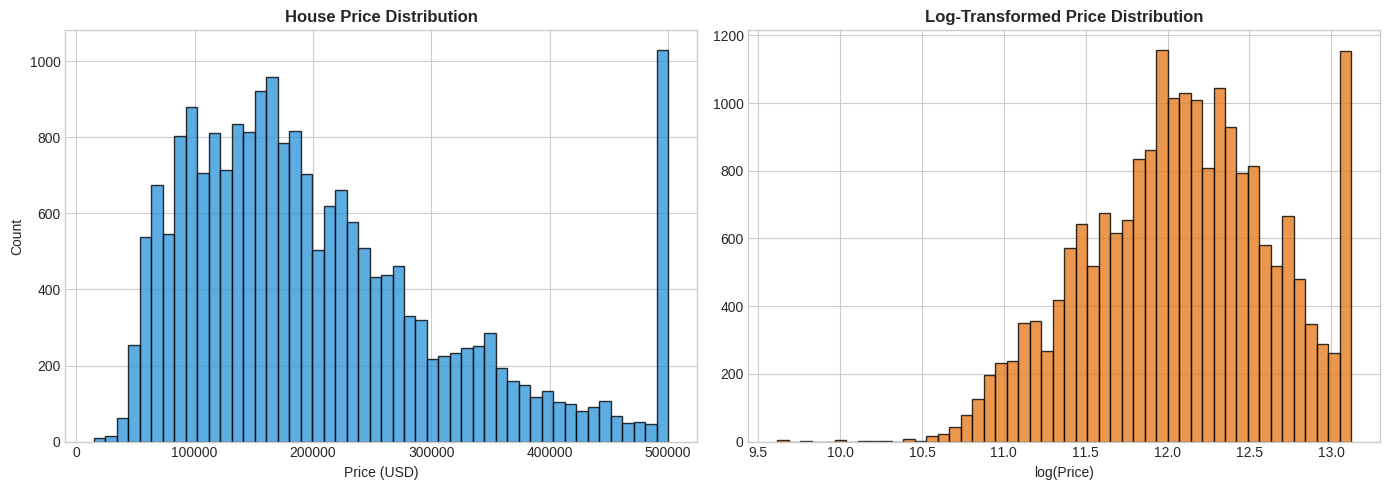

In [6]:
# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=50, color='#3498db', edgecolor='black', alpha=0.8)
axes[0].set_title('House Price Distribution', fontweight='bold')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['price']), bins=50, color='#e67e22', edgecolor='black', alpha=0.8)
axes[1].set_title('Log-Transformed Price Distribution', fontweight='bold')
axes[1].set_xlabel('log(Price)')

plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

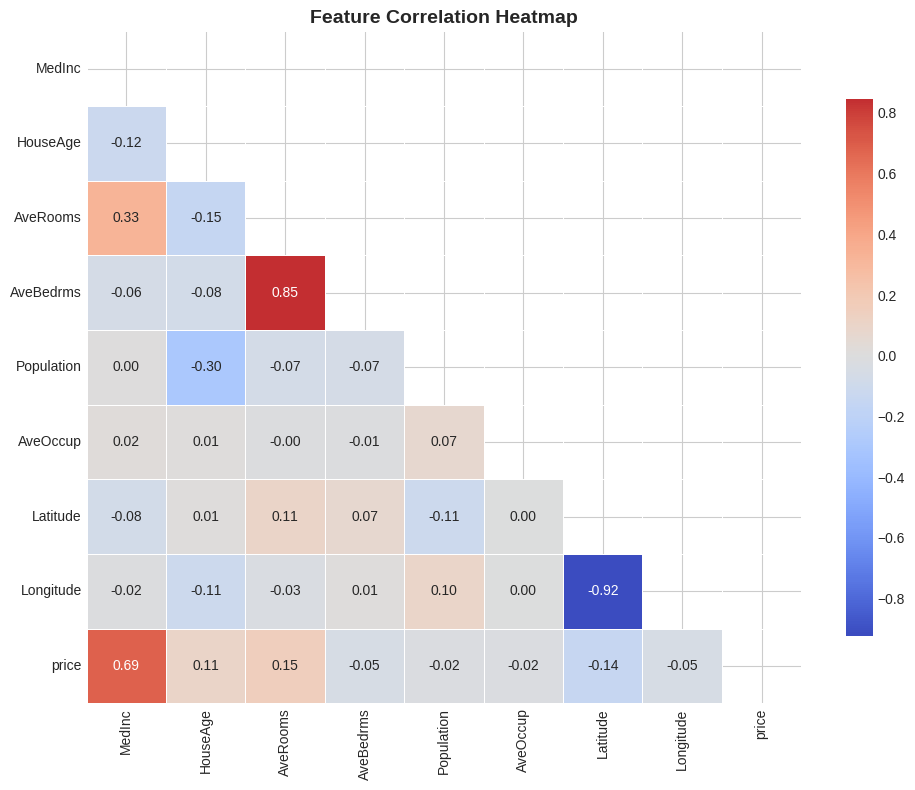

In [7]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

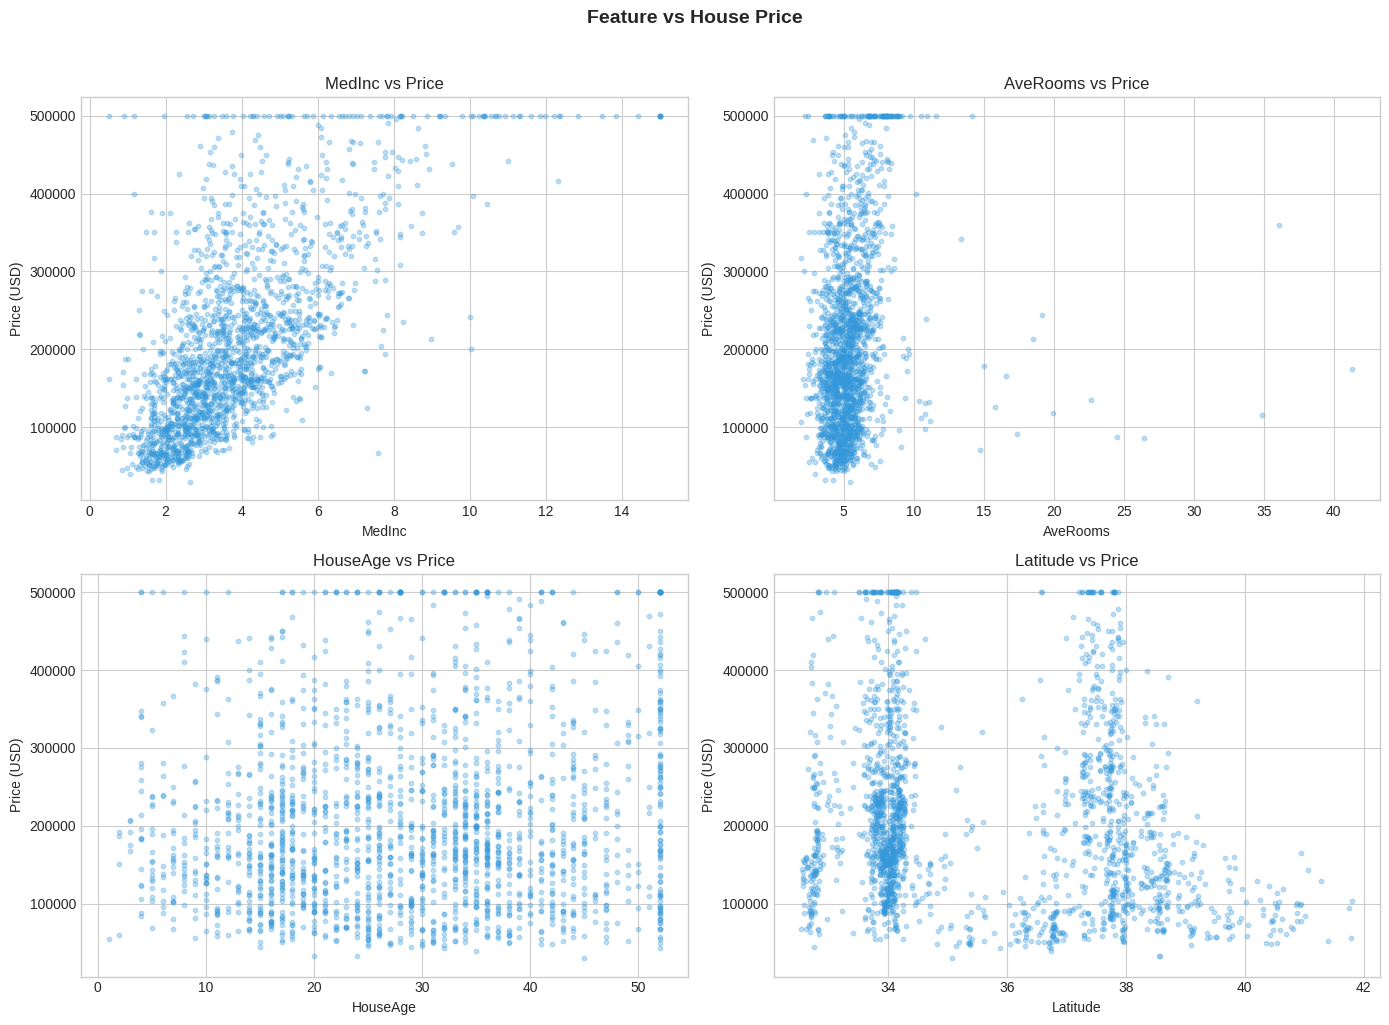

In [8]:
# Scatter plots for top correlated features
top_features = ['MedInc', 'AveRooms', 'HouseAge', 'Latitude']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    sample = df.sample(2000, random_state=42)
    axes[i].scatter(sample[feat], sample['price'], alpha=0.3, color='#3498db', s=10)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Price (USD)')
    axes[i].set_title(f'{feat} vs Price')

plt.suptitle('Feature vs House Price', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Feature Engineering
df['rooms_per_person']    = df['AveRooms']   / df['AveOccup']
df['bedrooms_per_room']   = df['AveBedrms']  / df['AveRooms']
df['population_density']  = df['Population'] / df['AveOccup']

# Features and target
FEATURE_COLS = [
    'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
    'Population', 'AveOccup', 'Latitude', 'Longitude',
    'rooms_per_person', 'bedrooms_per_room', 'population_density'
]

X = df[FEATURE_COLS]
y = df['price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 16512 | Test: 4128


In [10]:
def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'\n{name}')
    print(f'  MAE : ${mae:,.0f}')
    print(f'  RMSE: ${rmse:,.0f}')
    print(f'  R²  : {r2:.4f}')
    return {'Model': name, 'MAE': round(mae), 'RMSE': round(rmse), 'R2': round(r2, 4)}

results = []

In [11]:
# ── Linear Regression ─────────────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
results.append(evaluate_model('Linear Regression', y_test, y_pred_lr))


Linear Regression
  MAE : $48,744
  RMSE: $67,382
  R²  : 0.6535


In [12]:
# ── Ridge Regression ──────────────────────────────────────────────────────────
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)
y_pred_ridge = ridge.predict(X_test_sc)
results.append(evaluate_model('Ridge Regression', y_test, y_pred_ridge))


Ridge Regression
  MAE : $48,744
  RMSE: $67,382
  R²  : 0.6535


In [13]:
# ── Gradient Boosting Regressor ───────────────────────────────────────────────
print('Training Gradient Boosting... (~1-2 min)')
gbr = GradientBoostingRegressor(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    min_samples_split=5, random_state=42
)
gbr.fit(X_train, y_train)  # GBR doesn't need scaling
y_pred_gbr = gbr.predict(X_test)
results.append(evaluate_model('Gradient Boosting', y_test, y_pred_gbr))
print('Training complete ✅')

Training Gradient Boosting... (~1-2 min)

Gradient Boosting
  MAE : $31,054
  RMSE: $47,282
  R²  : 0.8294
Training complete ✅


In [14]:
results_df = pd.DataFrame(results)
print('\n=== Model Comparison ===')
print(results_df.to_string(index=False))


=== Model Comparison ===
            Model   MAE  RMSE     R2
Linear Regression 48744 67382 0.6535
 Ridge Regression 48744 67382 0.6535
Gradient Boosting 31054 47282 0.8294


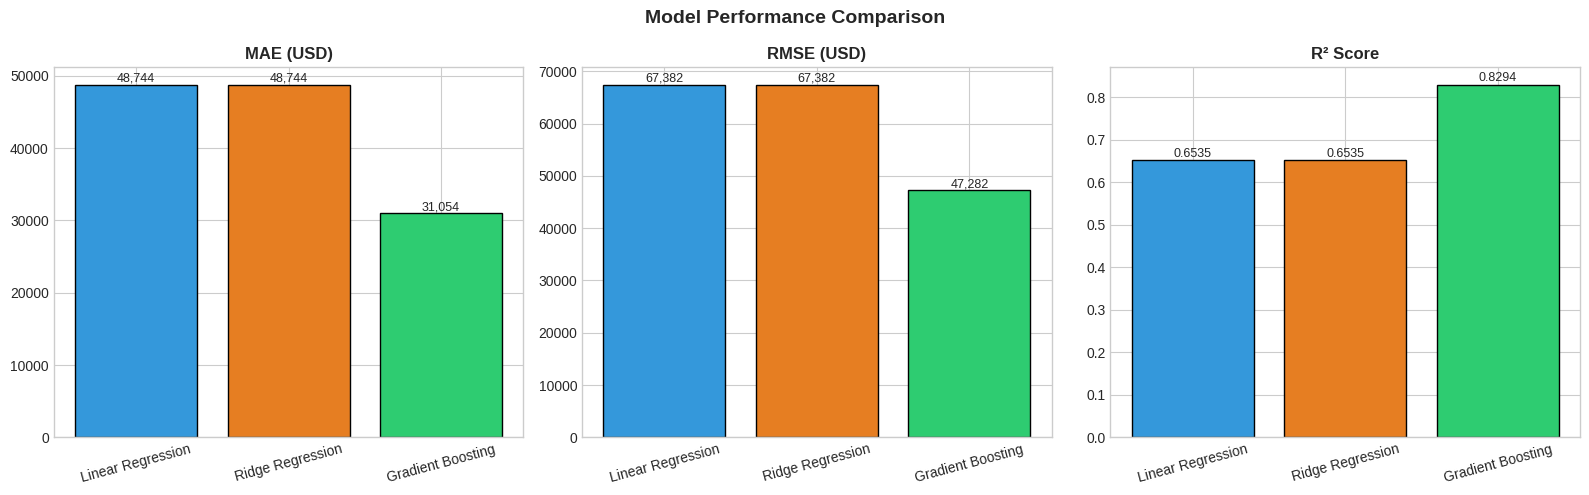

In [15]:
# Metric comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#3498db', '#e67e22', '#2ecc71']

for i, (metric, title) in enumerate([('MAE','MAE (USD)'), ('RMSE','RMSE (USD)'), ('R2','R² Score')]):
    axes[i].bar(results_df['Model'], results_df[metric], color=colors, edgecolor='black')
    axes[i].set_title(title, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=15)
    for j, v in enumerate(results_df[metric]):
        axes[i].text(j, v * 1.01, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

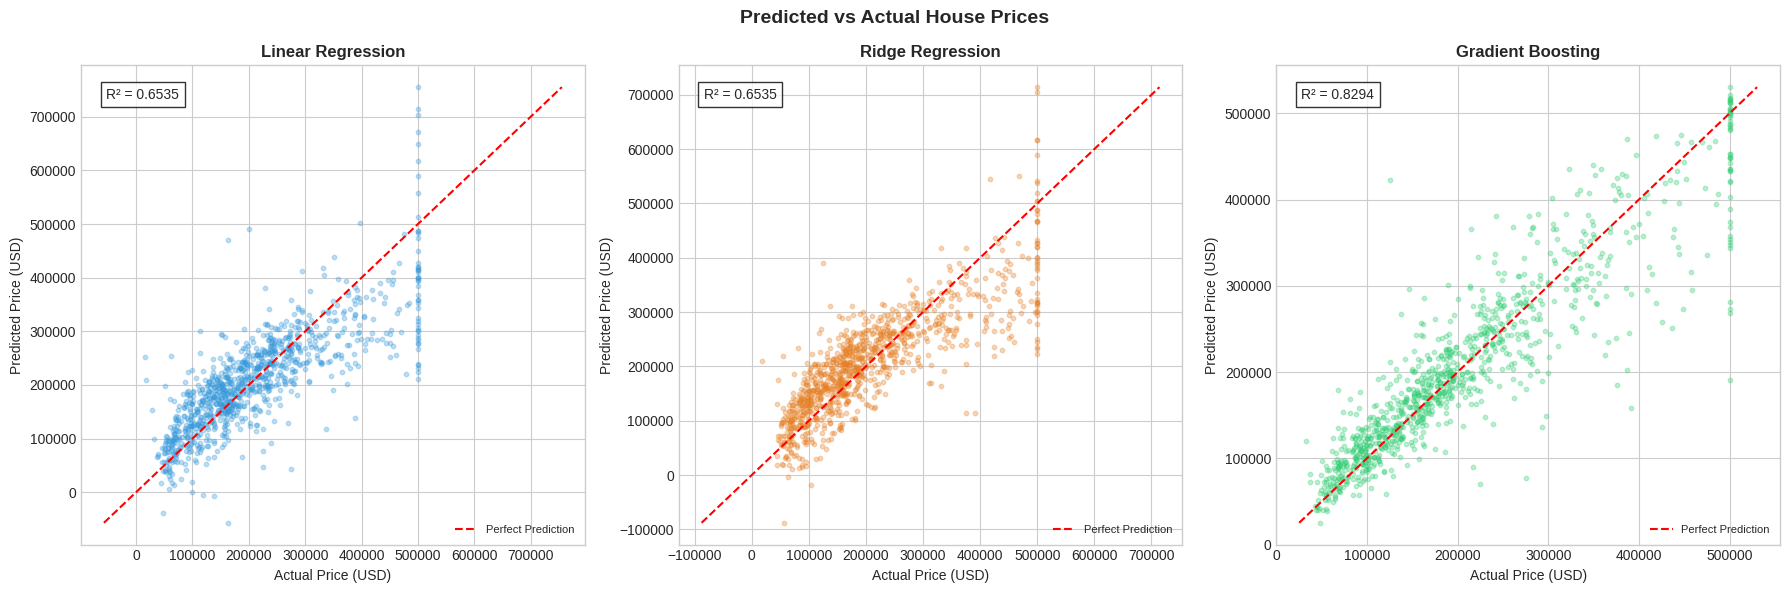

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models_info = [
    ('Linear Regression',  y_pred_lr,    '#3498db'),
    ('Ridge Regression',   y_pred_ridge, '#e67e22'),
    ('Gradient Boosting',  y_pred_gbr,   '#2ecc71')
]

for ax, (name, y_pred, color) in zip(axes, models_info):
    # Sample for readability
    idx = np.random.choice(len(y_test), min(1000, len(y_test)), replace=False)
    yt  = np.array(y_test)[idx]
    yp  = np.array(y_pred)[idx]

    ax.scatter(yt, yp, alpha=0.3, color=color, s=10)
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect Prediction')
    ax.set_xlabel('Actual Price (USD)')
    ax.set_ylabel('Predicted Price (USD)')
    ax.set_title(name, fontweight='bold')
    r2 = r2_score(y_test, y_pred)
    ax.text(0.05, 0.93, f'R² = {r2:.4f}', transform=ax.transAxes,
            fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
    ax.legend(fontsize=8)

plt.suptitle('Predicted vs Actual House Prices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

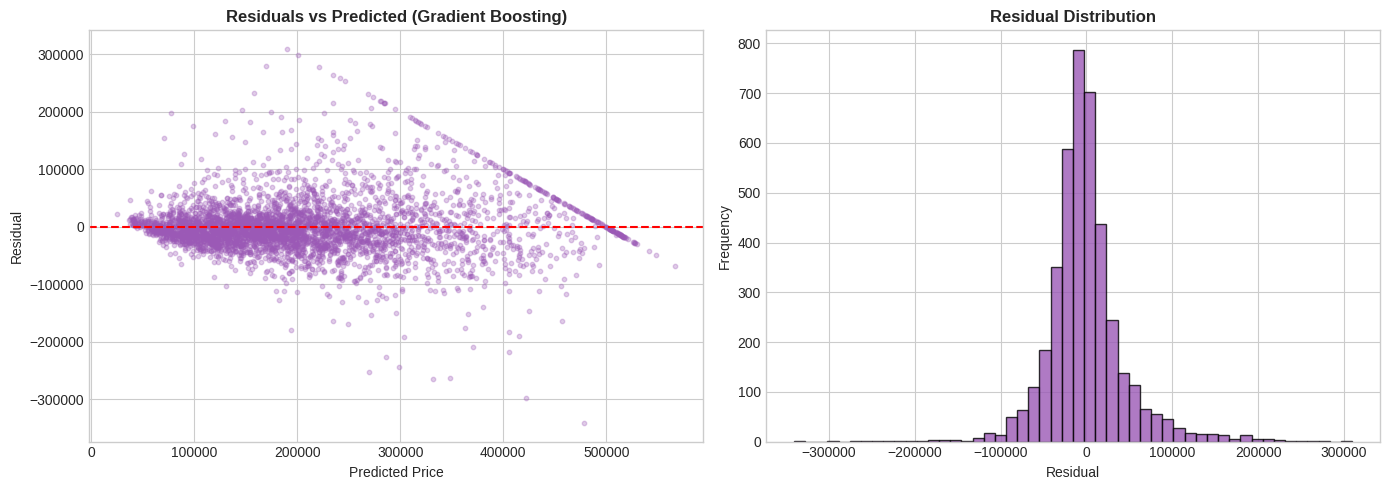

In [17]:
# Residual plot for best model (GBR)
residuals = y_test - y_pred_gbr

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_gbr, residuals, alpha=0.3, color='#9b59b6', s=10)
axes[0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0].set_xlabel('Predicted Price'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted (Gradient Boosting)', fontweight='bold')

axes[1].hist(residuals, bins=50, color='#9b59b6', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('residuals.png', dpi=150, bbox_inches='tight')
plt.show()

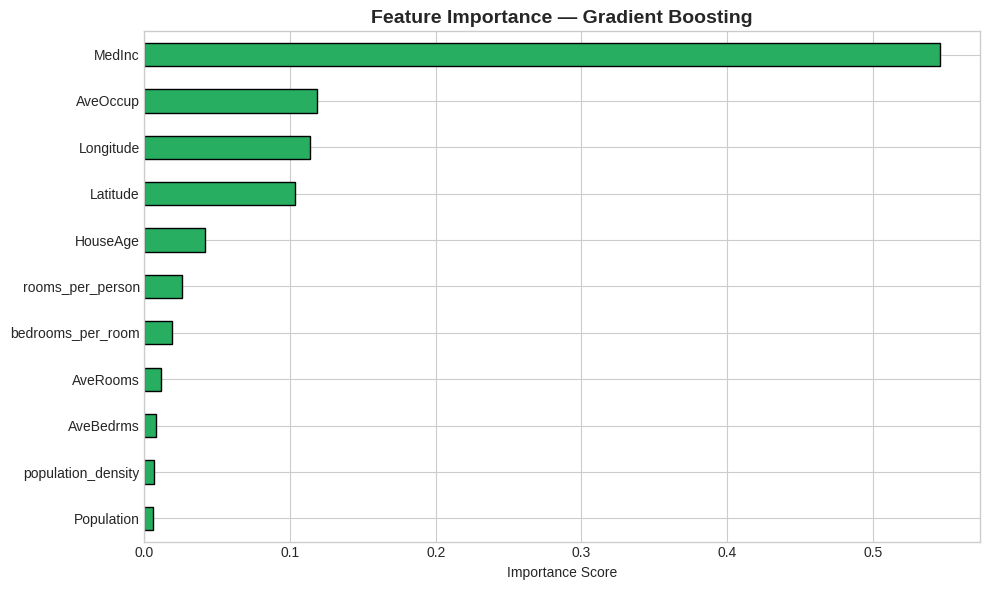


Top 5 Features:
MedInc       0.546363
AveOccup     0.118430
Longitude    0.113982
Latitude     0.103003
HouseAge     0.041279
dtype: float64


In [18]:
feature_imp = pd.Series(
    gbr.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_imp.plot(kind='barh', color='#27ae60', edgecolor='black')
plt.title('Feature Importance — Gradient Boosting', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 Features:')
print(feature_imp.sort_values(ascending=False).head())